In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import numpy as np

OUTDIR = "aggregated"

def plot_map(ds, var="seg_length_km", title="", cbar_label = "", savepath=None):
    """
    Plot a 2D map of the given variable from an xarray Dataset.
    Assumes dimensions: (flight_level, latitude, longitude).
    Sums over flight levels before plotting.
    """
    # --- Sum over altitude / flight levels ---
    data_2d = ds[var].sum(dim="altitude").squeeze()

    # Replace zeros with NaN for clarity
    data_np = data_2d.where(data_2d != 0).values

    lon = ds.longitude.values
    lat = ds.latitude.values

    # --- Setup map ---
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(14, 8)
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Plot data ---
    im = ax.imshow(
        data_np.T,  # transpose to match lon/lat orientation
        origin="lower",
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    )

    # --- Colorbar ---
    cbar = plt.colorbar(im, ax=ax, orientation="vertical", shrink=0.6)
    cbar.set_label(cbar_label)

    # --- Title ---
    ax.set_title(title, fontsize=14)

    plt.show()


def plot_outputs(file_dict, var="seg_length_km", outdir="maps"):
    """
    Loop over NetCDF outputs and plot maps.

    Parameters
    ----------
    file_dict : dict
        Dictionary of label → file paths (e.g., {(month, hour): path})
    var : str
        Variable name to plot (default: ef_per_m)
    outdir : str
        Directory where plots are saved
    """
    os.makedirs(outdir, exist_ok=True)
    for key, filepath in file_dict.items():
        try:
            ds = xr.open_dataset(filepath)
            print(ds)
            if isinstance(key, tuple):  # monthly/hourly
                month, hour = key
                title = f"Traffic | Month={month:02d}, Hour={hour:02d}"
                fname = f"map_month{month:02d}_hour{hour:02d}.png"
            else:  # monthly only
                month = key
                title = f"Traffic | Month={month:02d}"
                fname = f"map_month{month:02d}.png"

            savepath = os.path.join(outdir, fname)
            plot_map(ds, var=var, title=title, savepath=savepath)
            ds.close()
            print(f"✅ Saved {savepath}")
        except Exception as e:
            print(f"⚠️ Error plotting {filepath}: {e}")


In [18]:
ds = xr.open_dataset("aggregated/hourly_sum_01.nc")

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\GriddedForcing\\data-sharing-transport-environment\\aggregated\\hourly_sum_01.nc'

In [17]:
ds

<xarray.Dataset> Size: 644MB
Dimensions:                 (longitude: 1441, latitude: 721, altitude: 31)
Coordinates:
  * longitude               (longitude) float64 12kB -180.0 -179.8 ... 180.0
  * latitude                (latitude) float64 6kB -90.0 -89.75 ... 89.75 90.0
  * altitude                (altitude) float64 248B 6e+03 ... 1.514e+04
Data variables:
    total_flight_dist       (longitude, latitude, altitude) float32 129MB ...
    ef_net                  (longitude, latitude, altitude) float32 129MB ...
    ef_initial_loc          (longitude, latitude, altitude) float32 129MB ...
    ef_net_overlap          (longitude, latitude, altitude) float32 129MB ...
    ef_initial_loc_overlap  (longitude, latitude, altitude) float32 129MB ...

In [3]:
regions = {
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60},
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15},
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40},
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5},
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5},
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63},
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65},  # crosses dateline
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
    "Eurocontrol": {
            "lon_min": -30.0,
            "lon_max": 45.0,
            "lat_min": 25.0,
            "lat_max": 72.0
        }
}

def subset_region(ds, region):
    """Return subset of dataset within the region bounding box."""
    lon_min, lon_max = region["lon_min"], region["lon_max"]
    lat_min, lat_max = region["lat_min"], region["lat_max"]

    # Handle longitude wrap-around (e.g. North Pacific)
    if lon_min < lon_max:
        subset = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    else:
        # For regions crossing the dateline (e.g. 140E–120W)
        subset1 = ds.sel(longitude=slice(lon_min, 180))
        subset2 = ds.sel(longitude=slice(-180, lon_max))
        subset = xr.concat([subset1, subset2], dim="longitude")
        subset = subset.sel(latitude=slice(lat_min, lat_max))
    
    return subset

regional_stats = {}

for name, bbox in regions.items():
    ds_region = subset_region(ds, bbox)
    stats = {
        "ef_net_mean": float(ds_region["ef_net"].sum().values),
        "ef_initial_loc_mean": float(ds_region["ef_initial_loc_overlap"].sum().values),
        "total_flight_dist_sum": float(ds_region["total_flight_dist"].sum().values)
    }
    regional_stats[name] = stats

print(regional_stats)


KeyError: "No variable named 'ef_net'. Variables on the dataset include ['longitude', 'latitude', 'altitude', 'time', 'total_flight_dist']"

In [ ]:
for region, stats in regional_stats.items():
    print(f"\n=== {region} ===")
    for var, value in stats.items():
        print(f"{var:20s}: {value:.3e}")



=== USA ===
ef_net_mean         : 1.439e+20
ef_initial_loc_mean : 1.358e+20
total_flight_dist_sum: 1.242e+10

=== Europe ===
ef_net_mean         : 1.395e+20
ef_initial_loc_mean : 1.319e+20
total_flight_dist_sum: 7.014e+09

=== East_Asia ===
ef_net_mean         : 2.395e+19
ef_initial_loc_mean : 2.330e+19
total_flight_dist_sum: 6.830e+09

=== Southeast_Asia ===
ef_net_mean         : 4.017e+19
ef_initial_loc_mean : 3.979e+19
total_flight_dist_sum: 3.267e+09

=== Latin_America ===
ef_net_mean         : 1.974e+19
ef_initial_loc_mean : 1.986e+19
total_flight_dist_sum: 1.828e+09

=== Africa_Middle_East ===
ef_net_mean         : 3.026e+19
ef_initial_loc_mean : 3.075e+19
total_flight_dist_sum: 4.071e+09

=== China ===
ef_net_mean         : 3.252e+19
ef_initial_loc_mean : 3.050e+19
total_flight_dist_sum: 7.429e+09

=== India ===
ef_net_mean         : 1.210e+19
ef_initial_loc_mean : 1.194e+19
total_flight_dist_sum: 2.127e+09

=== North_Atlantic ===
ef_net_mean         : 9.294e+19
ef_initial_loc_

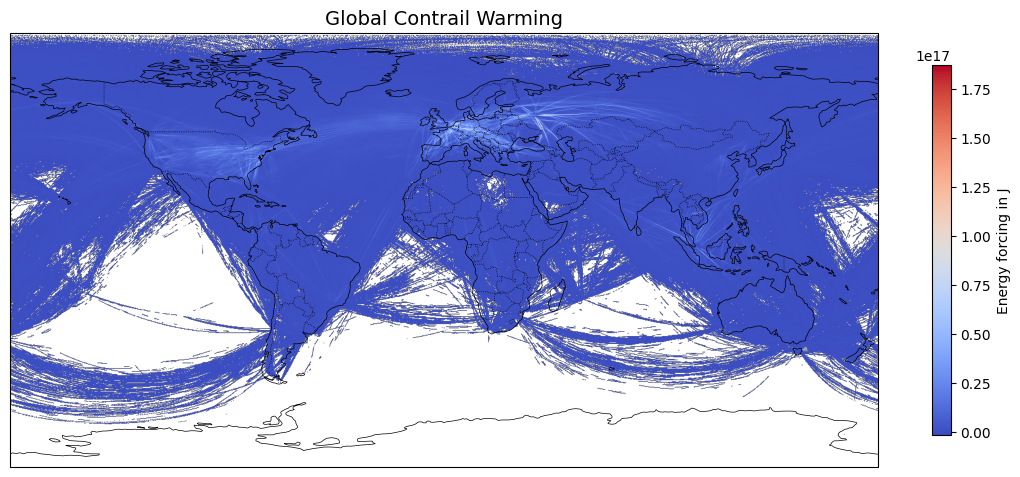

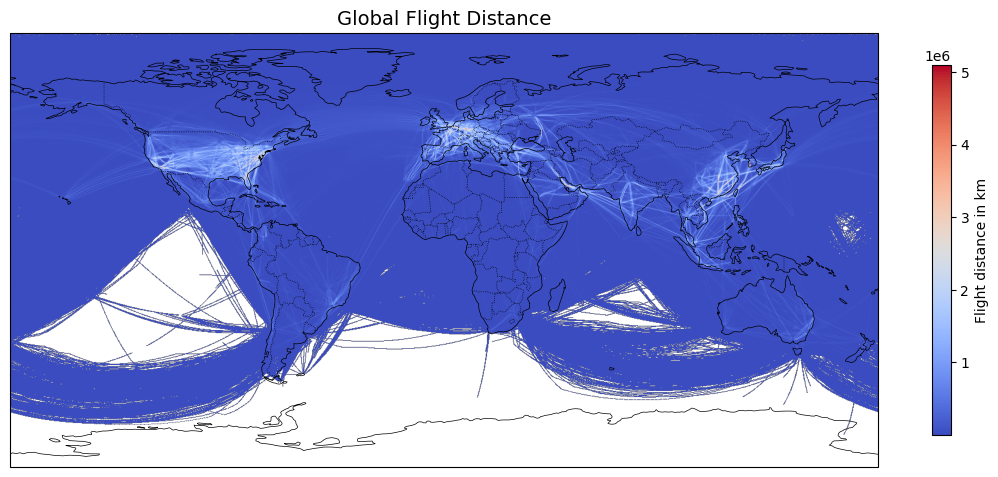

In [ ]:
plot_map(ds, var="ef_initial_loc_overlap", title="Global Contrail Warming", cbar_label="Energy forcing in J", savepath="")
plot_map(ds, var="total_flight_dist",      title="Global Flight Distance", cbar_label="Flight distance in km", savepath="")

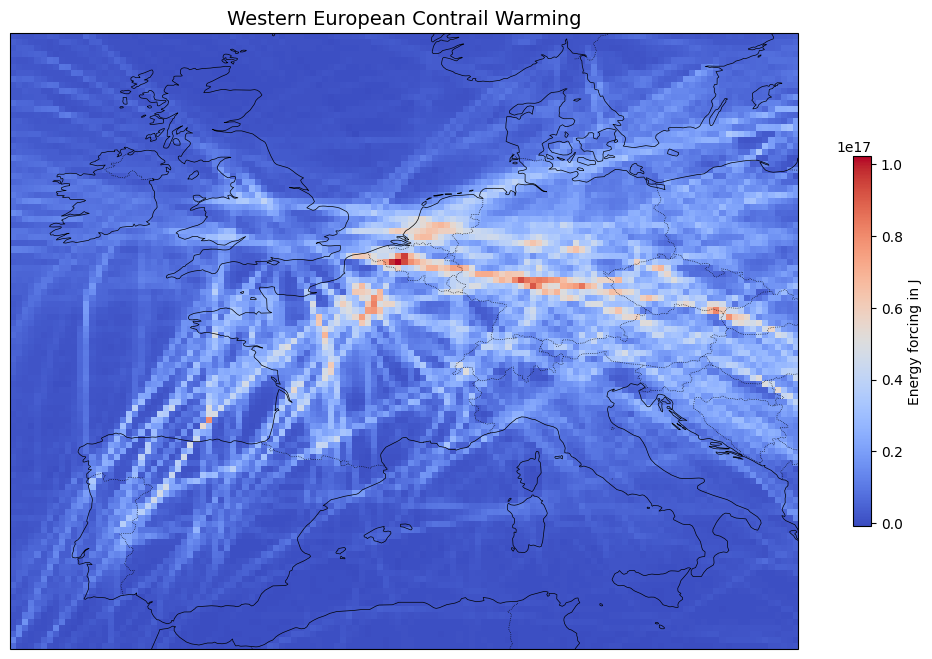

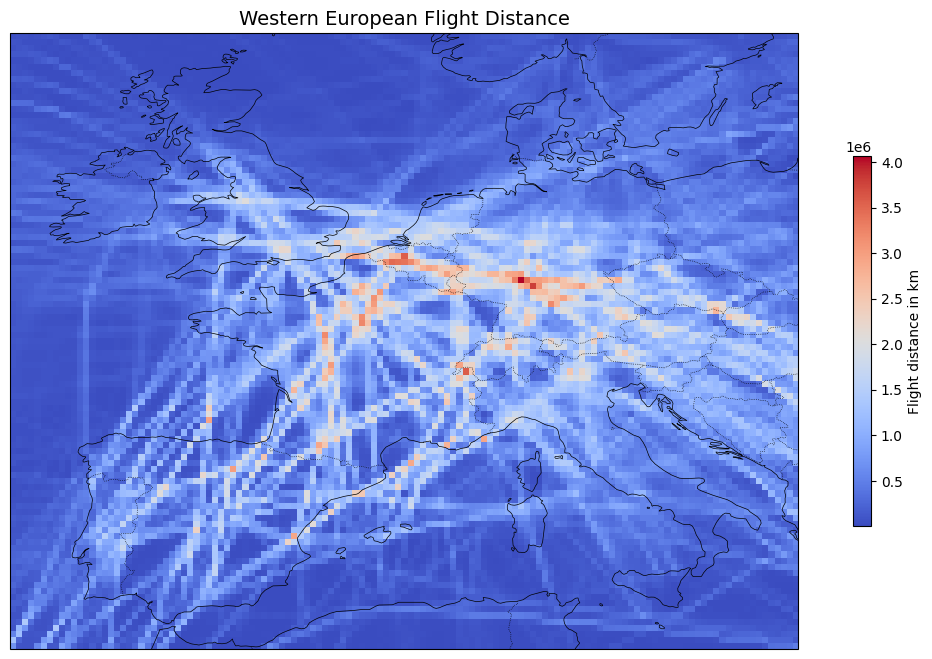

In [ ]:
plot_map(subset_region(ds, regions["Europe"]), var="ef_initial_loc_overlap", title="Western European Contrail Warming", cbar_label="Energy forcing in J", savepath="")
plot_map(subset_region(ds, regions["Europe"]), var="total_flight_dist",      title="Western European Flight Distance", cbar_label="Flight distance in km", savepath="")

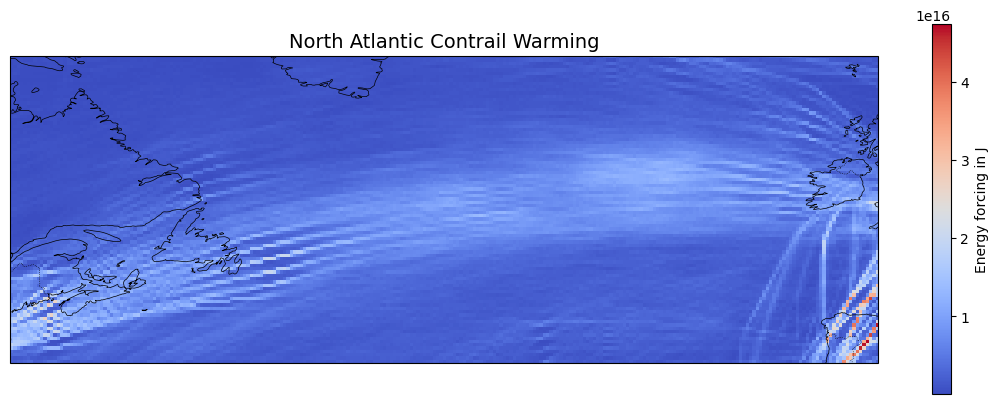

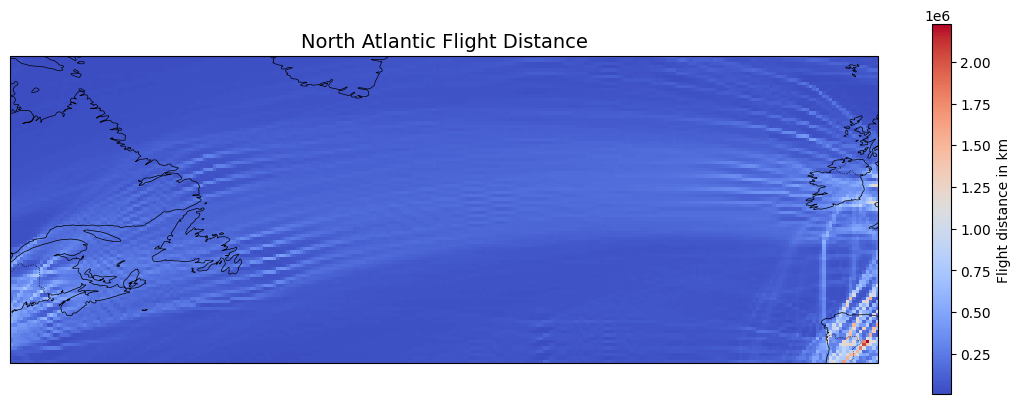

In [ ]:
plot_map(subset_region(ds, regions["North Atlantic"]), var="ef_initial_loc_overlap", title="North Atlantic Contrail Warming", cbar_label="Energy forcing in J", savepath="")
plot_map(subset_region(ds, regions["North Atlantic"]), var="total_flight_dist",      title="North Atlantic Flight Distance", cbar_label="Flight distance in km", savepath="")

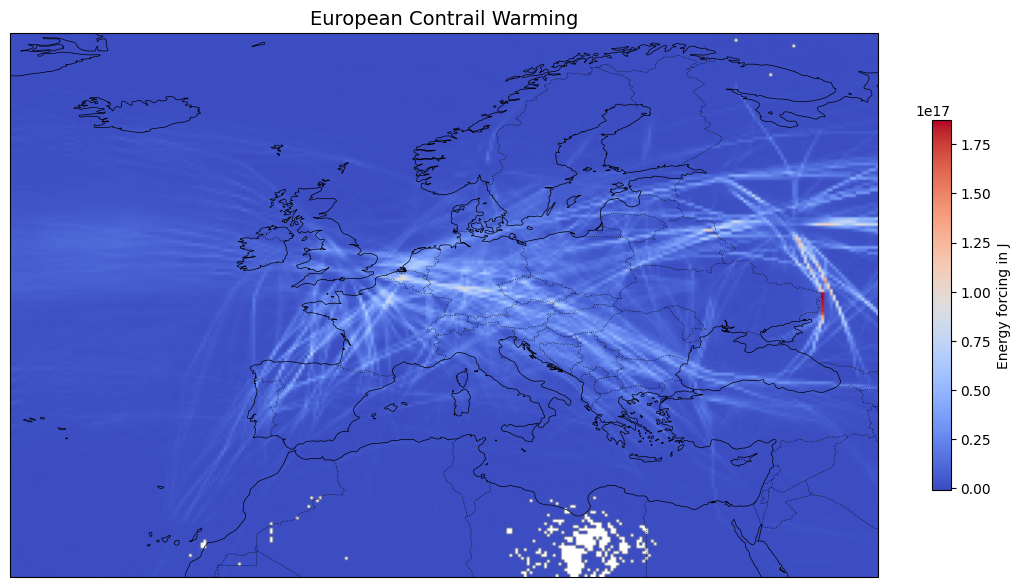

In [ ]:
plot_map(subset_region(ds, regions["Eurocontrol"]), var="ef_initial_loc_overlap", title="European Contrail Warming", cbar_label="Energy forcing in J", savepath="")
plot_map(subset_region(ds, regions["Eurocontrol"]), var="total_flight_dist", title="European Flight Distance", cbar_label="Flight distance in km", savepath="")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

def make_fl_bands(fl_step=25, fl_max=500):
    """
    Generate a dictionary of flight level bands in meters.

    Parameters
    ----------
    fl_step : int
        Step size in flight levels (hundreds of feet), e.g. 25 = 2500 ft.
    fl_max : int
        Maximum flight level (hundreds of feet), e.g. 500 = 50,000 ft.

    Returns
    -------
    dict
        Keys: band labels (e.g. 'FL000–025'), 
        Values: (lower_alt_m, upper_alt_m) tuples.
    """
    ft_to_m = 0.3048  # 1 ft = 0.3048 m
    fl_bands = {}
    for fl in range(0, fl_max, fl_step):
        fl_next = fl + fl_step
        label = f"FL{fl:03d}–{fl_next:03d}"
        fl_bands[label] = (fl * 100 * ft_to_m, fl_next * 100 * ft_to_m)
    return fl_bands

def plot_flightlevel_sums_aggregated(ds,
                                     var="total_flight_dist",
                                     altitude_name="altitude",
                                     title=None,
                                     savepath=None):
    """
    Aggregate and plot horizontal sums of two variables by ATM flight level bands.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with dimensions (longitude, latitude, altitude)
    var1, var2 : str
        Variable names to sum (e.g. "total_flight_dist", "ef_initial_loc_overlap")
    altitude_name : str
        Name of altitude dimension (default: "altitude")
    title : str
        Plot title
    savepath : str
        Optional path to save the figure
    """
    # --- Define finer flight level bands (in meters) ---
    fl_bands = make_fl_bands()

    # --- Sum horizontally first ---
    var_sum = ds[var].sum(dim=["longitude", "latitude"])
    alt = ds[altitude_name]

    # --- Aggregate per band ---
    var_agg = []
    labels = []

    for fl_label, (zmin, zmax) in fl_bands.items():
        mask = (alt >= zmin) & (alt < zmax)
        if mask.any():
            var_band = var_sum.where(mask, drop=True).sum()
            var_agg.append(var_band.item())
            labels.append(fl_label)

    # --- Convert to DataFrame for clarity ---
    df = pd.DataFrame({
        "Flight Level Band": labels,
        var: var_agg,
    }).set_index("Flight Level Band")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    width = 0.35
    x = np.arange(len(df))

    ax.bar(x - width/2, df[var], width, label=var, color="tab:blue")

    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=45)
    ax.set_ylabel("Summed Value")
    ax.set_xlabel("Flight Level Band")
    ax.set_title(title or "Horizontal Sums by ATM Flight Level Band")
    ax.legend()
    ax.grid(axis="y", linestyle=":")

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    return df


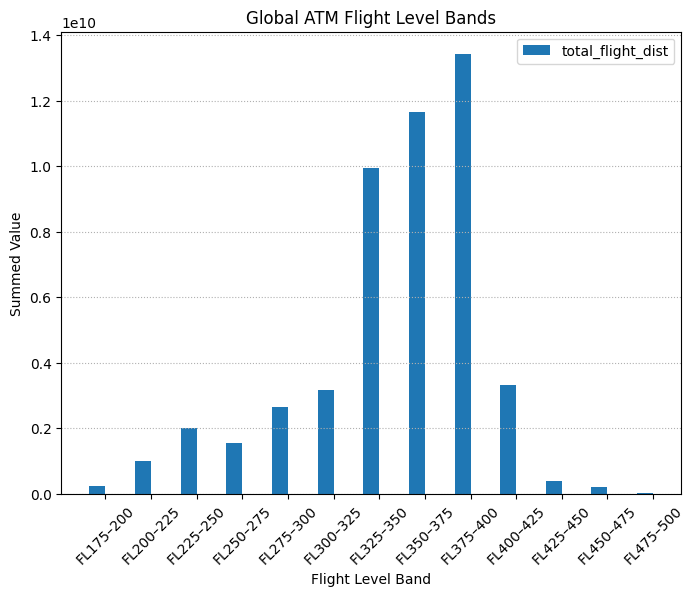

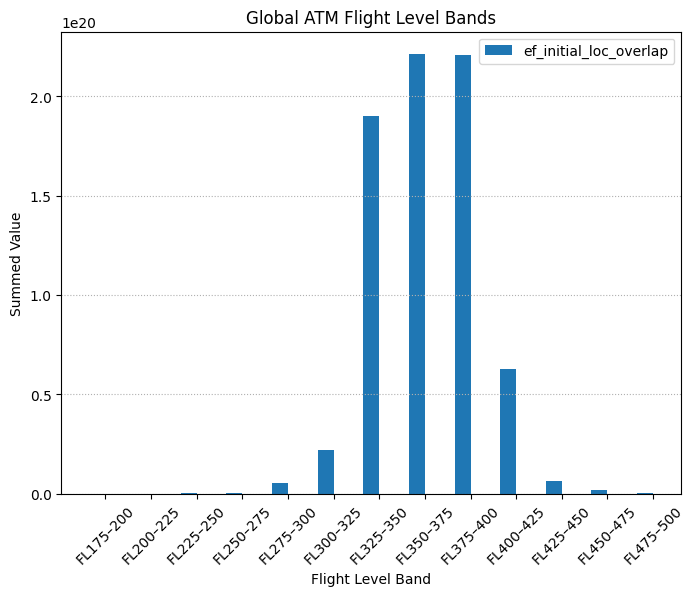

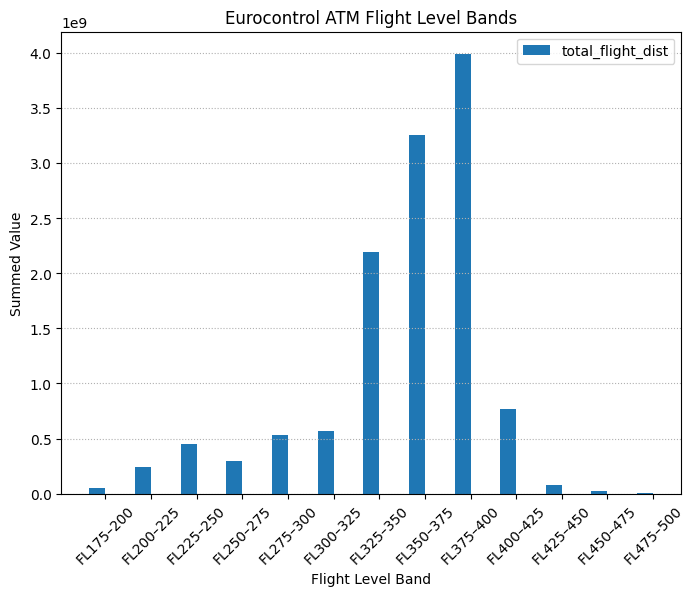

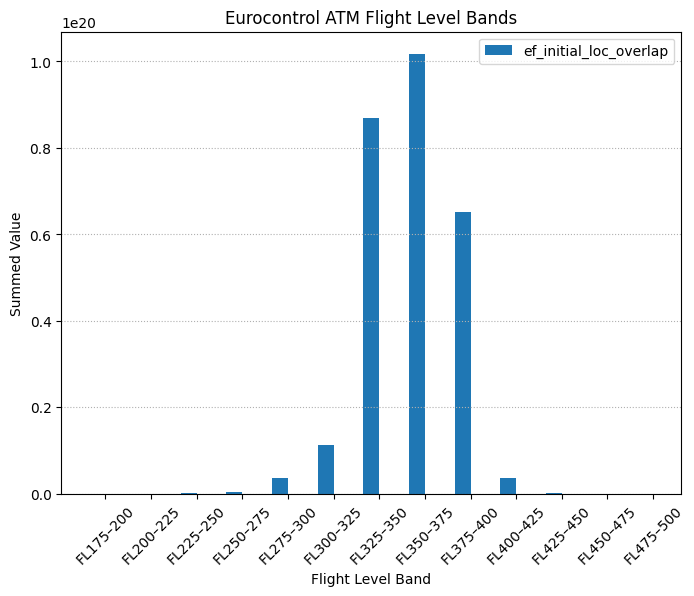

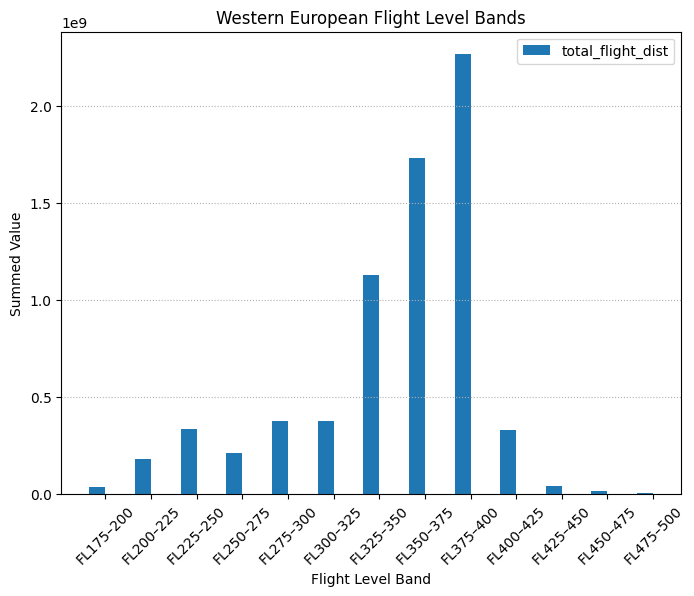

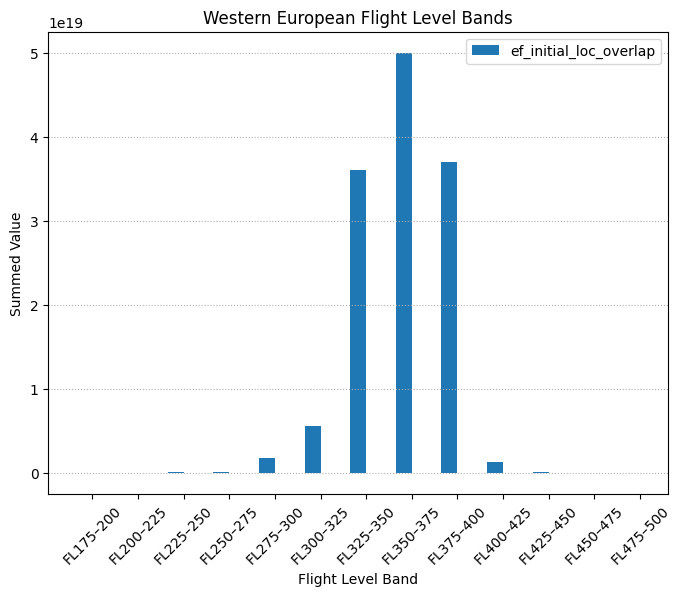

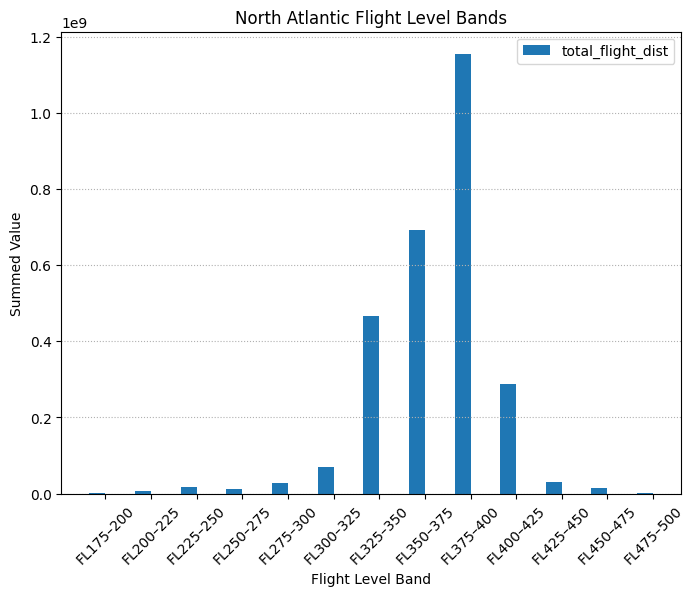

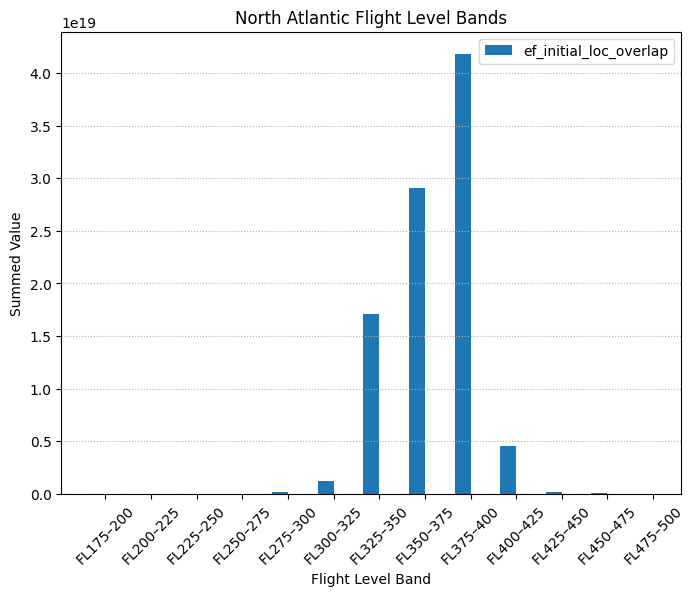

,ef_initial_loc_overlap
Flight Level Band,
FL175–200,0.000000e+00
FL200–225,3.804823e+13
FL225–250,1.459585e+15
FL250–275,4.020760e+15
FL275–300,1.678188e+17
FL300–325,1.200067e+18
FL325–350,1.705107e+19
FL350–375,2.907650e+19
FL375–400,4.185978e+19


In [ ]:

plot_flightlevel_sums_aggregated(ds, title = "Global ATM Flight Level Bands", var="total_flight_dist")
plot_flightlevel_sums_aggregated(ds, title = "Global ATM Flight Level Bands", var="ef_initial_loc_overlap")


plot_flightlevel_sums_aggregated(subset_region(ds, regions["Eurocontrol"]), title = "Eurocontrol ATM Flight Level Bands", var="total_flight_dist")
plot_flightlevel_sums_aggregated(subset_region(ds, regions["Eurocontrol"]), title = "Eurocontrol ATM Flight Level Bands", var="ef_initial_loc_overlap")

plot_flightlevel_sums_aggregated(subset_region(ds, regions["Europe"]), title = "Western European Flight Level Bands", var="total_flight_dist")
plot_flightlevel_sums_aggregated(subset_region(ds, regions["Europe"]), title = "Western European Flight Level Bands", var="ef_initial_loc_overlap")

plot_flightlevel_sums_aggregated(subset_region(ds, regions["North Atlantic"]), title = "North Atlantic Flight Level Bands", var="total_flight_dist")
plot_flightlevel_sums_aggregated(subset_region(ds, regions["North Atlantic"]), title = "North Atlantic Flight Level Bands", var="ef_initial_loc_overlap")

## Hourly Statistics

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

def plot_hourly_sum(
    folder,
    var,
    region=None,
    pattern="annual_hourly_sum_*.nc",
    title=None,
    savepath=None
):
    """
    Load hourly NetCDF files, sum a given variable, and plot totals by hour.

    Parameters
    ----------
    folder : str
        Path to folder containing annual_hourly_sum_XX.nc files.
    var : str
        Variable name to sum (e.g. 'ef_net', 'total_flight_dist').
    region : dict or None
        Optional bounding box (lon_min, lon_max, lat_min, lat_max)
        passed to `subset_region(ds, region)`.
    pattern : str
        Filename pattern for hourly NetCDFs (default: 'annual_hourly_sum_*.nc').
    title : str
        Optional plot title.
    savepath : str
        Optional path to save the plot.

    Returns
    -------
    pandas.DataFrame
        DataFrame of total variable by hour.
    """

    # --- Load all hourly files ---
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if not files:
        raise FileNotFoundError(f"No files found matching {pattern} in {folder}")

    hourly_totals = []
    hours = []

    for f in files:
        hour_str = os.path.basename(f).split("_")[-1].split(".")[0]
        try:
            hour = int(hour_str)
        except ValueError:
            continue

        ds = xr.open_dataset(f)

        # Optionally subset to a region
        if region is not None:
            ds = subset_region(ds, region)

        # Sum over all dimensions except time
        total_val = ds[var].sum().item()
        hourly_totals.append(total_val)
        hours.append(hour)

        ds.close()

    # --- Convert to arrays and sort by hour ---
    hours, hourly_totals = zip(*sorted(zip(hours, hourly_totals)))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(hours, hourly_totals, color="tab:blue", alpha=0.7)
    ax.set_xlabel("Hour of Day (UTC)")
    ax.set_ylabel(f"Total {var}")
    ax.set_xticks(range(0, 25))
    ax.grid(axis="y", linestyle=":")

    ax.set_title(title or f"Total {var} by Hour of Day", fontsize=14)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    # --- Return as DataFrame for further analysis ---
    import pandas as pd
    df = pd.DataFrame({"hour": hours, f"total_{var}": hourly_totals})
    return df


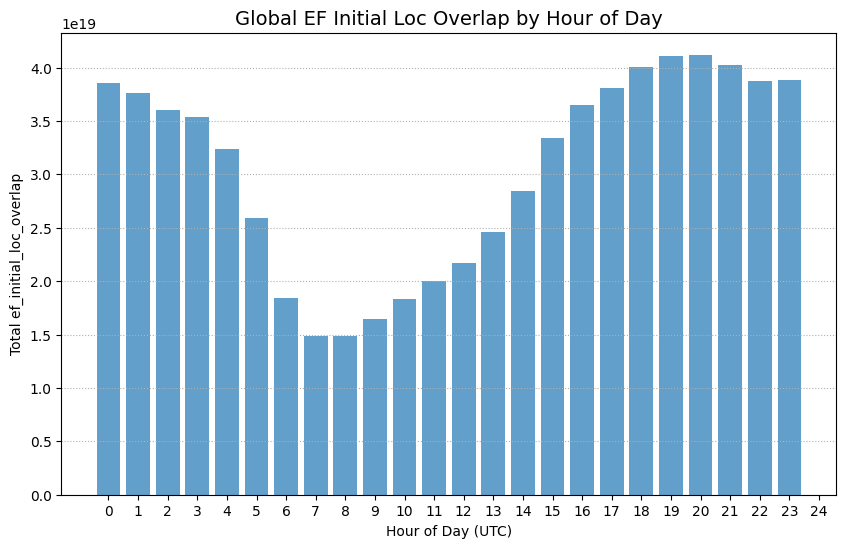

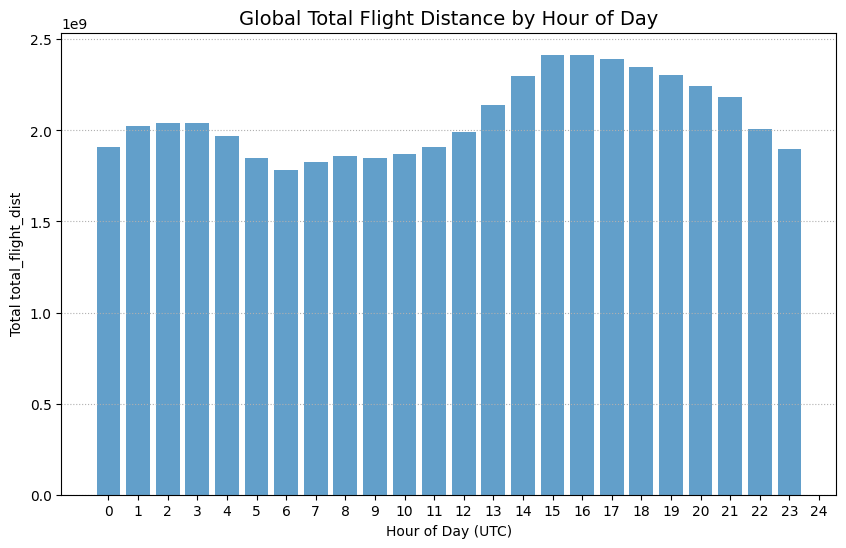

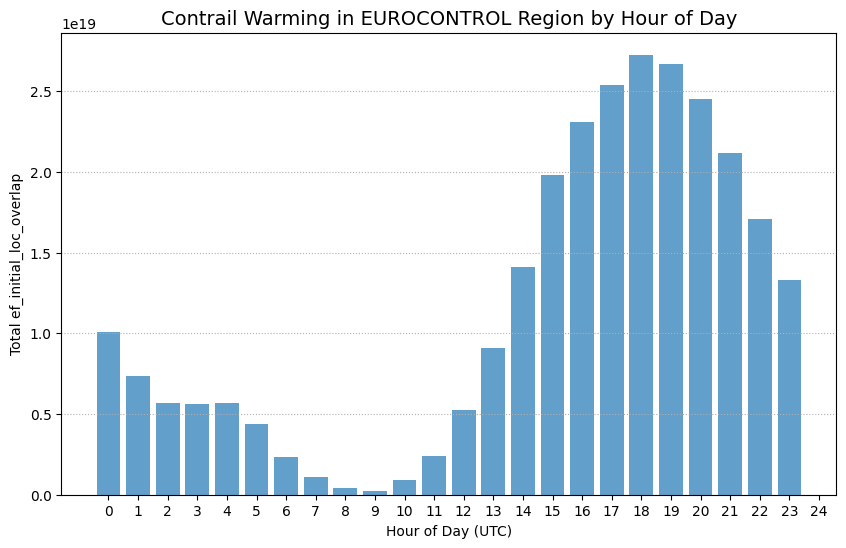

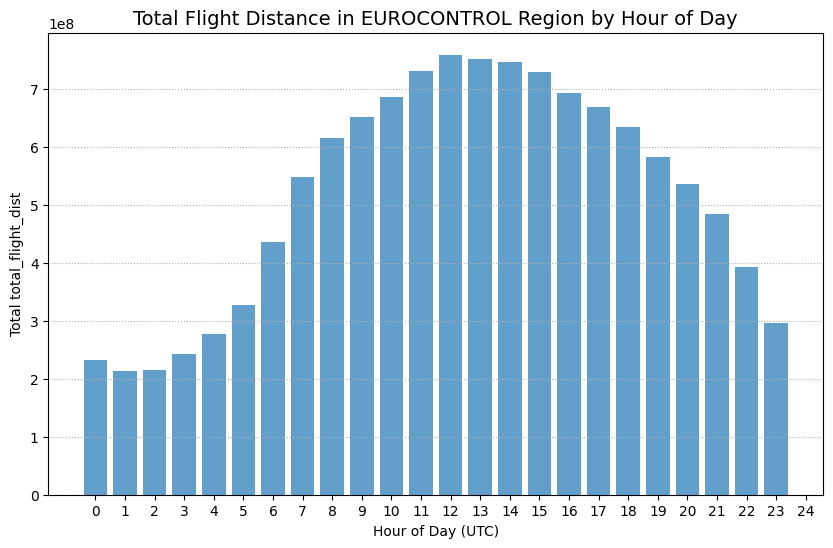

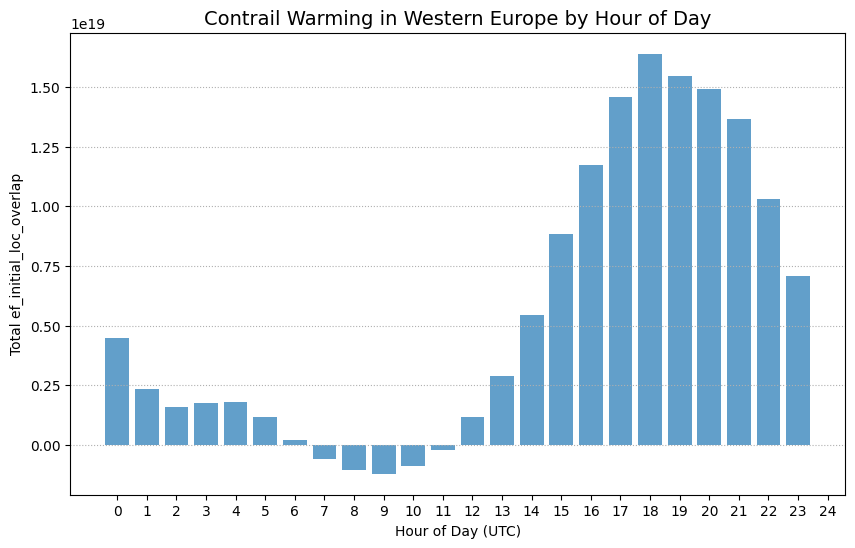

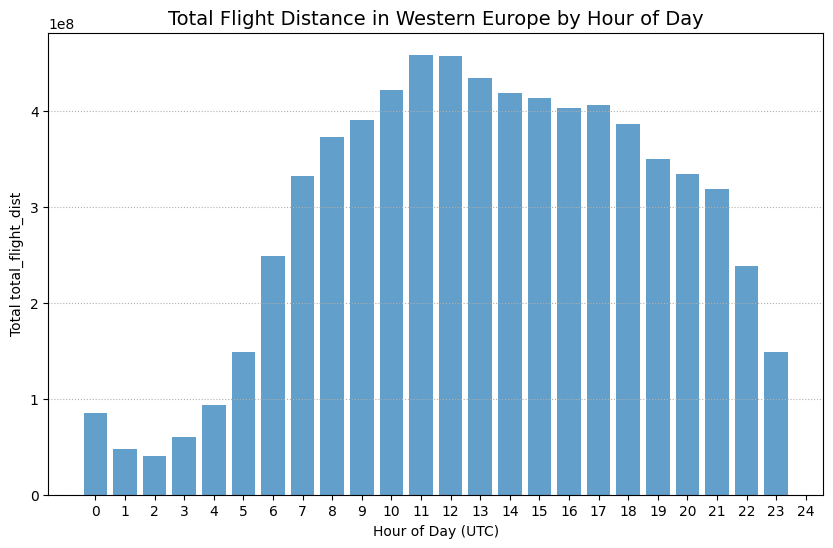

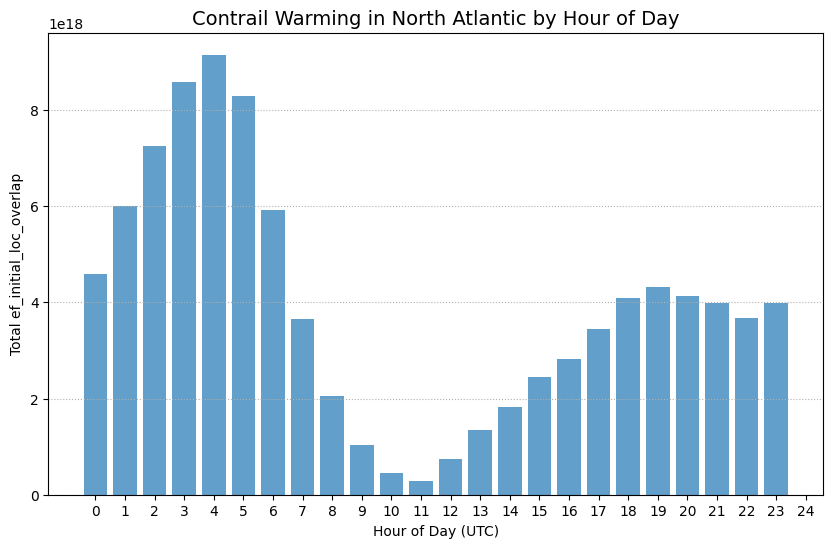

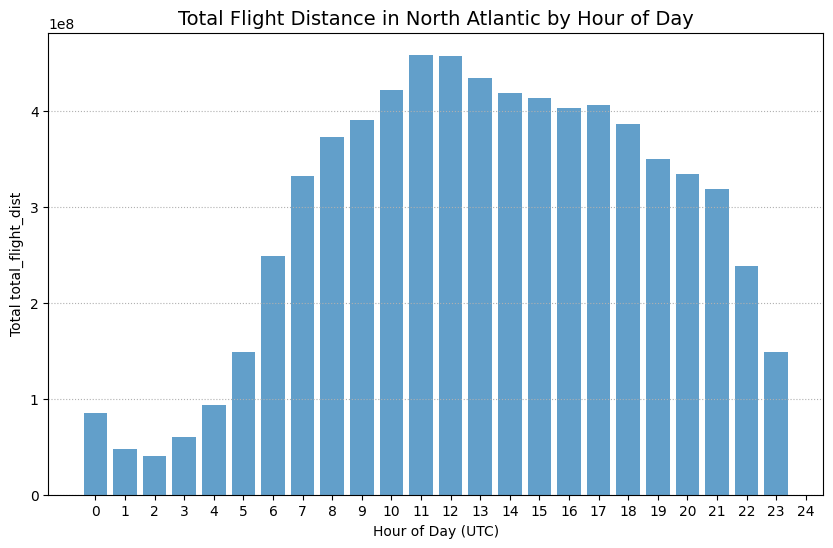

In [ ]:
# Option 1: Global totals
df_hourly = plot_hourly_sum(
    folder="aggregated",
    var="ef_initial_loc_overlap",
    title="Global EF Initial Loc Overlap by Hour of Day"
)

# Option 1: Global totals
df_hourly = plot_hourly_sum(
    folder="aggregated",
    var="total_flight_dist",
    title="Global Total Flight Distance by Hour of Day"
)

# Option 2: Regional totals (e.g. Eurocontrol)
df_hourly_region = plot_hourly_sum(
    folder="aggregated",
    var="ef_initial_loc_overlap",
    region=regions["Eurocontrol"],  # or any bounding box you defined earlier
    title="Contrail Warming in EUROCONTROL Region by Hour of Day"
)


df_hourly_region = plot_hourly_sum(
    folder="aggregated",
    var="total_flight_dist",
    region=regions["Eurocontrol"],  # or any bounding box you defined earlier
    title="Total Flight Distance in EUROCONTROL Region by Hour of Day"
)

# Option 2: Regional totals (e.g. Eurocontrol)
df_hourly_region = plot_hourly_sum(
    folder="aggregated",
    var="ef_initial_loc_overlap",
    region=regions["Europe"],  # or any bounding box you defined earlier
    title="Contrail Warming in Western Europe by Hour of Day"
)


df_hourly_region = plot_hourly_sum(
    folder="aggregated",
    var="total_flight_dist",
    region=regions["Europe"],  # or any bounding box you defined earlier
    title="Total Flight Distance in Western Europe by Hour of Day"
)

# Option 2: Regional totals (e.g. Eurocontrol)
df_hourly_region = plot_hourly_sum(
    folder="aggregated",
    var="ef_initial_loc_overlap",
    region=regions["North Atlantic"],  # or any bounding box you defined earlier
    title="Contrail Warming in North Atlantic by Hour of Day"
)


df_hourly_region = plot_hourly_sum(
    folder="aggregated",
    var="total_flight_dist",
    region=regions["Europe"],  # or any bounding box you defined earlier
    title="Total Flight Distance in North Atlantic by Hour of Day"
)


## Monthly statistics

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

def plot_monthly_sum(
    folder,
    var,
    region=None,
    pattern="monthly_sum_*.nc",
    title=None,
    savepath=None
):
    """
    Load hourly NetCDF files, sum a given variable, and plot totals by hour.

    Parameters
    ----------
    folder : str
        Path to folder containing monthly_sum_XX.nc files.
    var : str
        Variable name to sum (e.g. 'ef_net', 'total_flight_dist').
    region : dict or None
        Optional bounding box (lon_min, lon_max, lat_min, lat_max)
        passed to `subset_region(ds, region)`.
    pattern : str
        Filename pattern for hourly NetCDFs (default: 'monthly_sum_*.nc').
    title : str
        Optional plot title.
    savepath : str
        Optional path to save the plot.

    Returns
    -------
    pandas.DataFrame
        DataFrame of total variable by hour.
    """

    # --- Load all monthly files ---
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if not files:
        raise FileNotFoundError(f"No files found matching {pattern} in {folder}")

    monthly_totals = []
    months = []

    for f in files:
        month_str = os.path.basename(f).split("_")[-1].split(".")[0]
        try:
            month = int(month_str)
        except ValueError:
            continue

        ds = xr.open_dataset(f)

        # Optionally subset to a region
        if region is not None:
            ds = subset_region(ds, region)

        # Sum over all dimensions except time
        total_val = ds[var].sum().item()
        monthly_totals.append(total_val)
        months.append(month)

        ds.close()

    # --- Convert to arrays and sort by month ---
    months, monthly_totals = zip(*sorted(zip(months, monthly_totals)))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(months, monthly_totals, color="tab:blue", alpha=0.7)
    ax.set_xlabel("Month of the Year")
    ax.set_ylabel(f"Total {var}")
    ax.set_xticks(range(0, 13))
    ax.grid(axis="y", linestyle=":")

    ax.set_title(title or f"Total {var} by Month of the Year", fontsize=14)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    # --- Return as DataFrame for further analysis ---
    import pandas as pd
    df = pd.DataFrame({"month": months, f"total_{var}": monthly_totals})
    return df


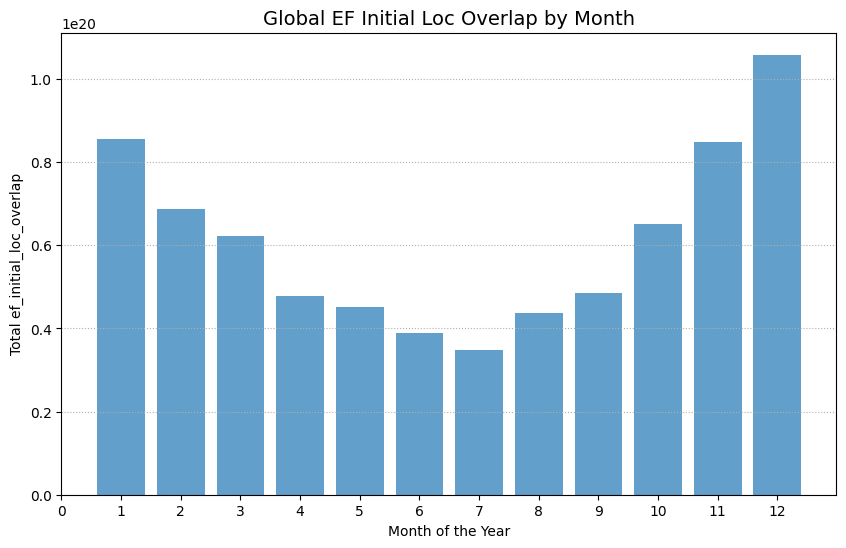

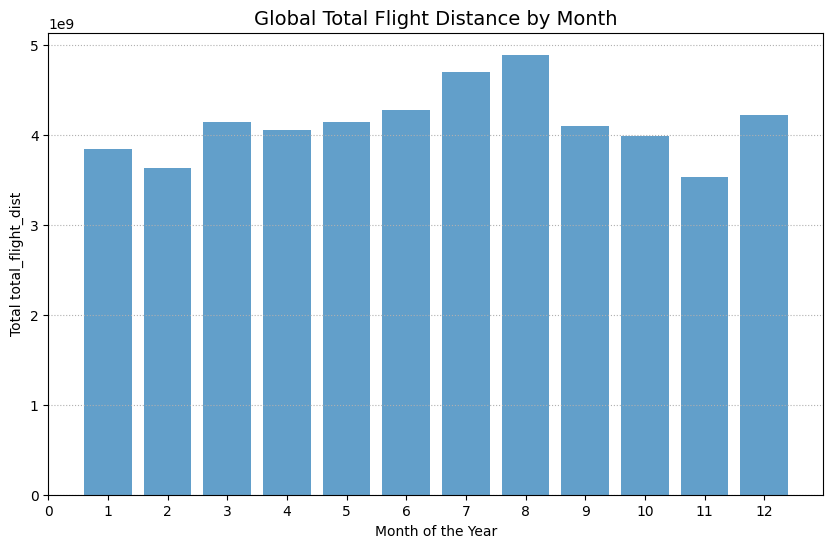

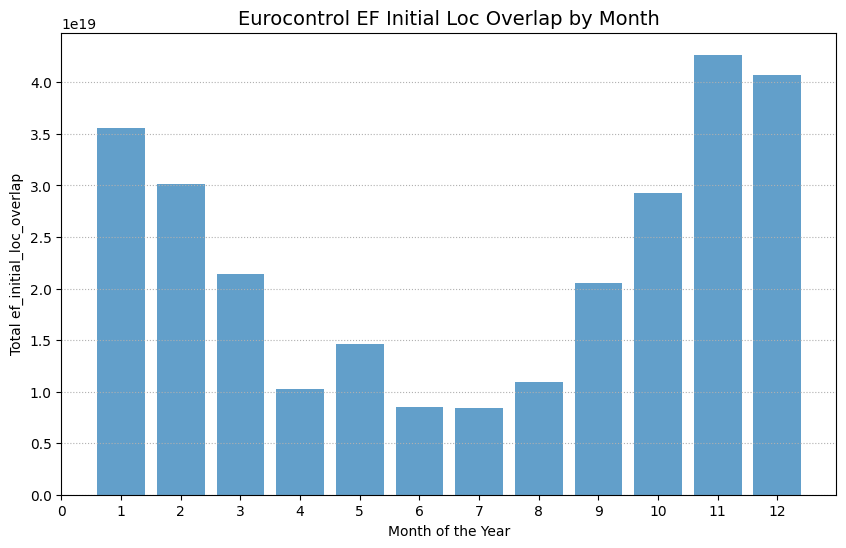

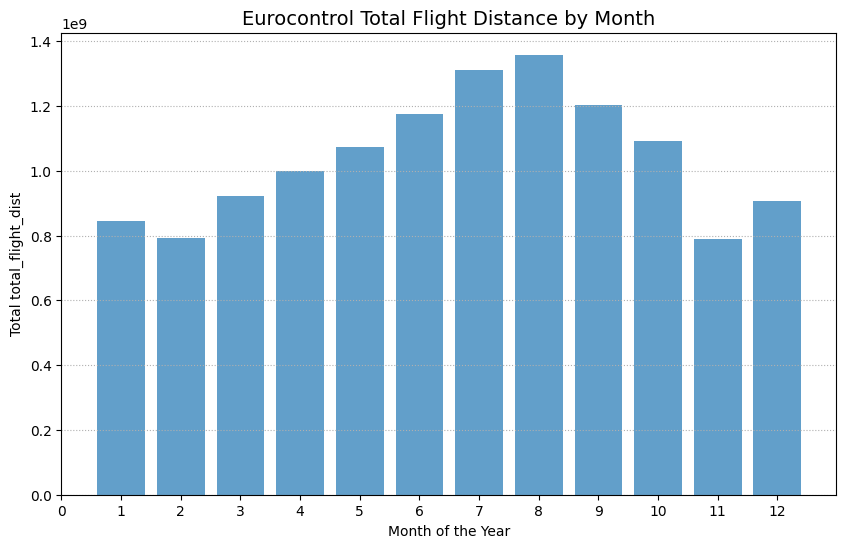

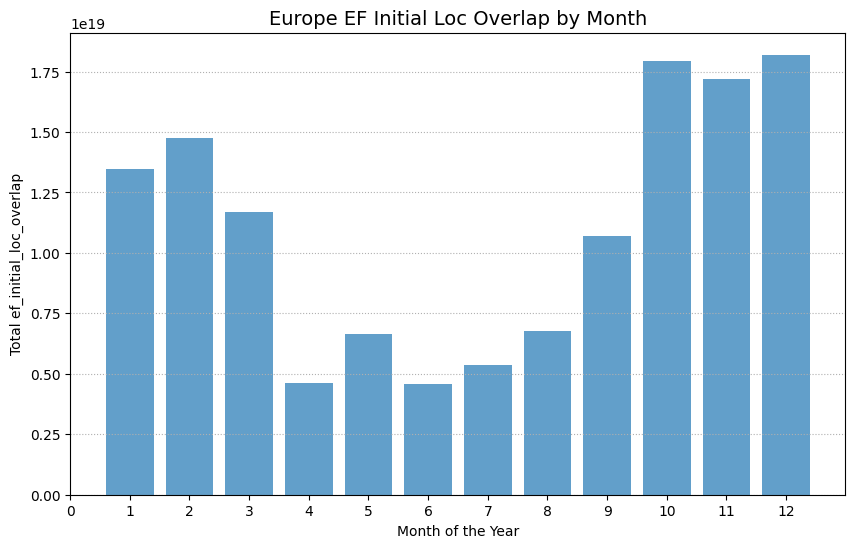

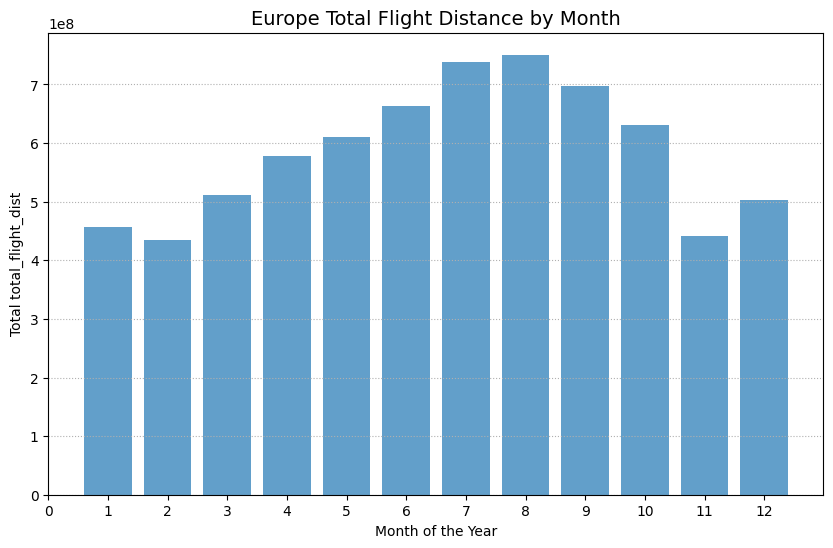

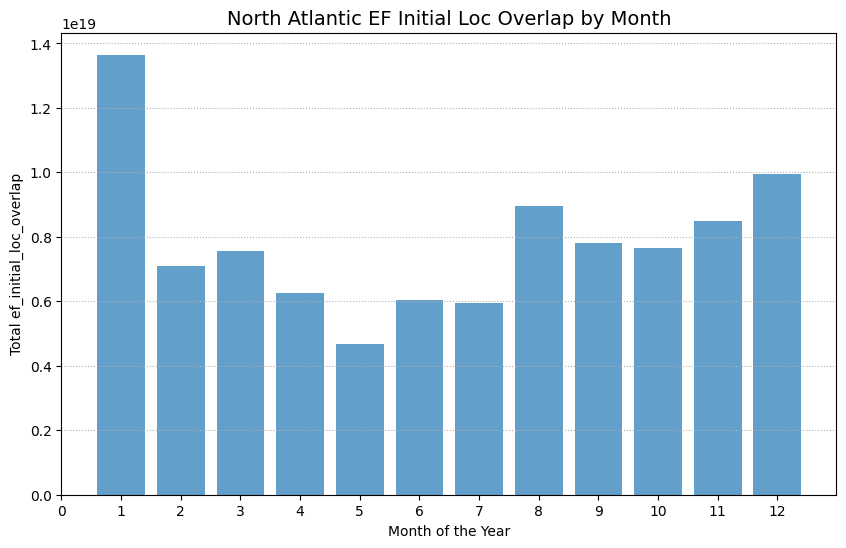

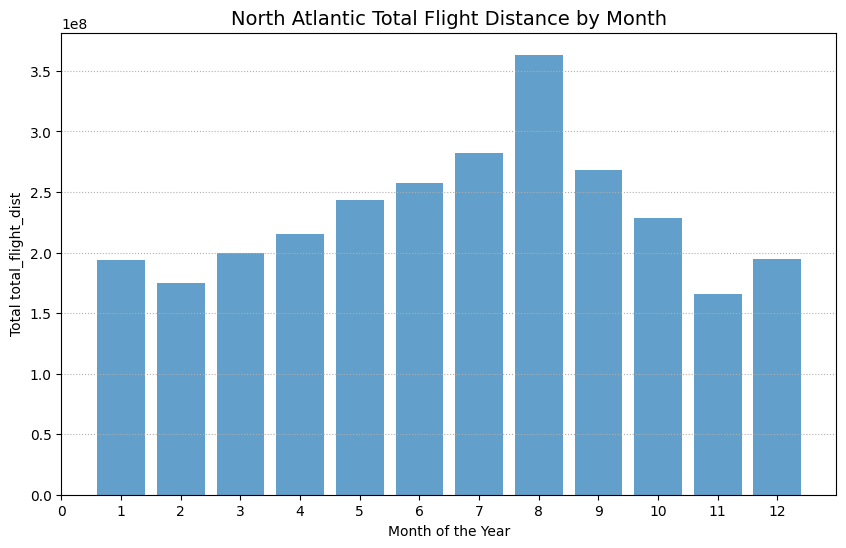

In [ ]:
# Option 1: Global totals
_ = plot_monthly_sum(
    folder="aggregated",
    var="ef_initial_loc_overlap",
    title="Global EF Initial Loc Overlap by Month"
)

_ = plot_monthly_sum(
    folder="aggregated",
    var="total_flight_dist",
    title="Global Total Flight Distance by Month"
)

_ = plot_monthly_sum(
    folder="aggregated",
    region = regions["Eurocontrol"],
    var="ef_initial_loc_overlap",
    title="Eurocontrol EF Initial Loc Overlap by Month"
)

_ = plot_monthly_sum(
    region = regions["Eurocontrol"],
    folder="aggregated",
    var="total_flight_dist",
    title="Eurocontrol Total Flight Distance by Month"
)

_ = plot_monthly_sum(
    folder="aggregated",
    region = regions["Europe"],
    var="ef_initial_loc_overlap",
    title="Europe EF Initial Loc Overlap by Month"
)

_ = plot_monthly_sum(
    region = regions["Europe"],
    folder="aggregated",
    var="total_flight_dist",
    title="Europe Total Flight Distance by Month"
)
_ = plot_monthly_sum(
    folder="aggregated",
    region = regions["North Atlantic"],
    var="ef_initial_loc_overlap",
    title="North Atlantic EF Initial Loc Overlap by Month"
)

_ = plot_monthly_sum(
    region = regions["North Atlantic"],
    folder="aggregated",
    var="total_flight_dist",
    title="North Atlantic Total Flight Distance by Month"
)



## Breakdown by FIR

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Load FIR polygons ---
firs = gpd.read_file("worldfirs.json")

# If CRS is missing, assume lon/lat (WGS84)
if firs.crs is None:
    firs = firs.set_crs(epsg=4326)

# --- Plot with Cartopy ---
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add background features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True)

# Plot FIR polygons
firs.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)

plt.title("FIR polygons overlay (check CRS alignment)")
plt.show()


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Load FIR polygons ---
firs = gpd.read_file("worldfirs.json")

# If CRS is missing, assume lon/lat (WGS84)
if firs.crs is None:
    firs = firs.set_crs(epsg=4326)

# --- Plot with Cartopy ---
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add background features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True)

# --- Set Eurocontrol bounding box ---
bbox = {
    "lon_min": -30.0,
    "lon_max": 45.0,
    "lat_min": 25.0,
    "lat_max": 72.0
}
ax.set_extent([bbox["lon_min"], bbox["lon_max"], bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())

# Plot FIR polygons
firs.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)

plt.title("FIR polygons overlay (Eurocontrol region)")
plt.show()


In [ ]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point


OUTDIR = "aggregated"
# --- Load the FIR polygons ---
firs = gpd.read_file("worldfirs.json")  # your FIR geojson file

# If the CRS is missing, set it to WGS84 (EPSG:4326)
if firs.crs is None:
    firs = firs.set_crs(epsg=4326)
firs = firs.to_crs(epsg=4326)  # ensure it's in lon/lat WGS84

# --- Extract the data from the xarray dataset ---
# Assuming your dataset is already loaded as `ds`
# We'll collapse the altitude dimension, summing seg_length_km across it
filepath = os.path.join(OUTDIR, f"annual_sum.nc")
ds = xr.open_dataset(filepath)
seg_km_2d = ds["total_flight_distance"].sum(dim="altitude")

# Flatten the data into a DataFrame of lon, lat, seg_length
lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values, indexing="ij")
df = pd.DataFrame({
    "lon": lon.ravel(),
    "lat": lat.ravel(),
    "seg_km": seg_km_2d.values.ravel()
})


# Convert to GeoDataFrame for spatial join
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# --- Spatial join: assign each grid point to an FIR polygon ---
joined = gpd.sjoin(gdf, firs, how="inner", predicate="within")

# Aggregate by FIR designator (or name)
traffic_by_fir = joined.groupby("name")["seg_km"].sum().sort_values(ascending=False)

# --- Compute FIR area in km² (equal-area projection) ---
firs_equal_area = firs.to_crs("EPSG:6933")  # Cylindrical Equal Area projection
firs["area_km2"] = firs_equal_area.geometry.area / 1e6

# --- Merge traffic with area ---
traffic_area = traffic_by_fir.reset_index().merge(
    firs[["name", "area_km2"]],
    on="name", how="left"
)

# Add normalized metric: traffic density
traffic_area["traffic_density"] = traffic_area["seg_km"] / traffic_area["area_km2"]

# --- Plot absolute traffic (top 20 FIRs) ---
plt.figure(figsize=(10,6))
traffic_area.sort_values("seg_km", ascending=False).head(20).plot(
    kind="bar", x="name", y="seg_km", legend=False, color="steelblue"
)
plt.ylabel("Flight distance (km)")
plt.xlabel("FIR")
plt.title("Top FIRs by Flight Kilometers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --- Plot traffic density (top 20 FIRs) ---
plt.figure(figsize=(10,6))
traffic_area.sort_values("traffic_density", ascending=False).head(20).plot(
    kind="bar", x="name", y="traffic_density", legend=False, color="darkorange"
)
plt.ylabel("Flight distance per km²")
plt.xlabel("FIR")
plt.title("Top FIRs by Traffic Density")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()